# Smoothed TV image inpainting

```{admonition} Download sources
:class: download
* {download}`Python script <./demo_smoothed_tv_inpainting.py>`
* {download}`Jupyter notebook <./demo_smoothed_tv_inpainting.ipynb>`
```

This demo solves a variational image inpainting problem on the
unit square. A synthetic image is masked on an irregular interior region,
and the missing values are reconstructed using smoothed total
variation (TV) regularization.

## Problem Definition

Let $\Omega = [0,1]^2$ be the image domain. We define:

- $u_{\mathrm{true}}$: synthetic ground-truth image
- $m$: mask, equal to 1 on known data and 0 on the missing region
- $f = m u_{\mathrm{true}}$: observed incomplete image
- $u$: reconstructed image

We compute $u$ by minimising

$$
J(u)= {1 \over 2}\beta \int_\Omega m(u-f)^2\,\mathrm{d}x
+ \alpha \int_\Omega \sqrt{||\nabla u||^2 + \varepsilon^2}~\mathrm{d}x.
$$

The first term enforces agreement with the known image data, while
the second term is a smoothed total variation regularisation term.
It promotes piecewise smooth solution and preserves edges
$\alpha$  and $\beta$ control the balance between the data fidelity
(fit to f) and smoothness.
The parameter $\varepsilon>0$ smooths the TV function so that
it is differentiable and can be solved with Newton type methods.

## Discretization
We discretize the problem using
- a first order Lagrange finite element space
- a triangular mesh of the unit square

## Implementation

We use a first-order Lagrange space on a triangular mesh
of the unit square.
The nonlinear problem is solved with
{py:class}`PETSc SNES<petsc4py.PETSc.SNES>` through
{py:class}`NonlinearProblem <dolfinx.fem.petsc.NonlinearProblem>`.

In [63]:
from mpi4py import MPI

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np

import ufl
from dolfinx import fem, mesh, plot
from dolfinx.fem.petsc import NonlinearProblem
import pyvista


We discretize the domain $\Omega =[0,1]^2$ using a triangular
mesh, where `nx` and `ny` control the resolution of the mesh.

In [64]:
nx = 128
ny = 128
msh = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny)

We use [first order Lagrange elements](https://defelement.org/elements/examples/triangle-lagrange-equispaced-1.html) for discretizing the image.


In [65]:
V = fem.functionspace(msh, ("Lagrange", 1))

### Ground Truth image $u_{true}$
We define a synthetic binary image

$$
  u_{true}=\begin{cases}
  1 & \text{ if } (x,y) \text{ is inside a square},\\
  0 &\text{ otherwise}.
  \end{cases}
$$

The square is defined as $0.2<x<0.8, ~0.2<y<0.8$, which
gives a piecewise-constant image with sharp edges

In [66]:
def true_image(x):
    """Define a binary image with a square in the center."""
    X, Y, _ = x
    return ((X > 0.2) & (X < 0.8) & (Y > 0.2) & (Y < 0.8)).astype(np.float64)

### Mask $m(x,y)$
The mask defines which pixel are known and which are missing

$$
  m(x,y)=\begin{cases}
  1& \text{ known data},\\
  0 & \text{ missing region}.
  \end{cases}
$$

We construct a mask with random "holes" inside the square
* small circular regions are removed and set to 0
* everyhere else remains known (1)

This creates a challenging inpainting problem as:
* many small missing regions
* irregular geometry

The solver must reconstruct these missing values
using smoothness (TV regularization)

In [67]:
def mask_function(x, num_speckles=50, seed=0):
    """Create a mask with random circular holes inside the square.
    
    Args:
        x: The coordinates of the mesh points (x, y, z).
        num_speckles: The number of circular holes to create.
        seed: Random seed number for the center of the circular holes.

    """
    X, Y, _ = x

    # all pixels stat as known
    mask = np.ones_like(X, dtype=np.float64)

    # random centers
    generator = np.random.Generator(np.random.MT19937(seed))
    cx = generator.uniform(0.2, 0.8, num_speckles)
    cy = generator.uniform(0.2, 0.8, num_speckles)

    # random radii (small + varied)
    radii = generator.uniform(0.01, 0.03, num_speckles)

    # create holes. mask =0 inside circles
    for i in range(num_speckles):
        r2 = (X - cx[i]) ** 2 + (Y - cy[i]) ** 2
        mask[r2 < radii[i] ** 2] = 0.0
    return mask

We interpolate the exact image and the mask into the finite element
space, and construct the observed damaged image,
where $u_{true}$ is our true image, $m: \Omega \to \mathbb{R}$
is the mask, $f: \Omega \to \mathbb{R}$ is the observed damaged image,
and $u:\Omega \to \mathbb{R}$ is the reconstructed image.

In [68]:
u_true = fem.Function(V, name="true_image")
u_true.interpolate(true_image)
m = fem.Function(V, name="mask")
m.interpolate(mask_function)
f = fem.Function(V, name="observed_image")
f.x.array[:] = m.x.array * u_true.x.array

We visualize the true and observed image with Pyvista before solving the problem

In [69]:
grid = pyvista.UnstructuredGrid(*plot.vtk_mesh(V))
grid.point_data["true_image"] = u_true.x.array
grid.point_data["observed_image"] = f.x.array

plotter = pyvista.Plotter(shape=(1, 2))
plotter.subplot(0, 0)
plotter.add_text("True Image", font_size=12)
plotter.add_mesh(grid, scalars="true_image", cmap="gray")
plotter.subplot(0, 1)
plotter.add_text("Observed Image", font_size=12)
plotter.add_mesh(grid, scalars="observed_image", cmap="gray")
plotter.link_views()
plotter.view_xy()
plotter.show()

Widget(value='<iframe src="http://localhost:36035/index.html?ui=P_0x7a1c045fdbe0_9&reconnect=auto" class="pyvi…

We now define the nonlinear variational problem corresponding to the
smoothed total variation regularised inpainting model.

The Euler-Lagrange equation for $J(u)$ leads to the weak form
Find $u\in V$ such that

$$
\int_\Omega m(u-f)v\,\mathrm{d}x
+ \alpha \int_\Omega
{\nabla u\cdot\nabla v \over \sqrt{||\nabla u||^2+\varepsilon^2}}
\,\mathrm{d}x = 0
$$

for all test functions $v$. This is a nonlinear problem due to
the TV term
Total variation is usually defined as $\vert\vert\nabla u\vert\vert$,
but in practice one uses a smoothed version to allow for differentiation
and Newton type solvers:

$$
  TV = \sqrt{\vert\vert\nabla u\vert\vert^2 +\varepsilon^2}
$$

where # $\varepsilon$ is the smoothing of the TV:
* large $\varepsilon$ smoother more like quadratic diffusion
* small $\varepsilon$ closer to true TV edge pereserving

In [70]:
alpha = fem.Constant(msh, 0.003)
beta = fem.Constant(msh, 1.0)
eps = fem.Constant(msh, 1.0e-4)

Smoothed TV inpainting weak form
where $TV=||\nabla u||_2 +\varepsilon^2$:

$$
F(u) = \int m (u-f)v dx
+ \alpha \int {\nabla u \cdot \nabla v \over \sqrt{TV}}
$$

In [71]:
u = fem.Function(V, name="reconstructed_image")
grad_u = ufl.grad(u)
tv_denom = ufl.sqrt(ufl.inner(grad_u, grad_u) + eps**2)

In [72]:
v = ufl.TestFunction(V)
F = beta * m * (u - f) * v * ufl.dx + alpha * ufl.inner(grad_u, ufl.grad(v)) / tv_denom * ufl.dx

This formulation is based on total variation (TV) regulaization
for image denoising and inpainting
{cite:t}`tv-RUDIN1992TV,tv-CHAN2001TV`.

A nonlinear PETSc problem is created and solved with a Newton line-search
method, with an LU factorization for the linearized system
$J(u_k) s= -F(u_k)$.
We initialize the non-linear problem with the observed image

In [73]:
u.x.array[:] = f.x.array
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_rtol": 1.0e-8,
    "snes_atol": 1.0e-8,
    "snes_max_it": 1000,
    "ksp_type": "preonly",
    "pc_type": "lu",
}

problem = NonlinearProblem(
    F,
    u,
    bcs=[],
    petsc_options_prefix="tv_inpainting_",
    petsc_options=petsc_options,
)

problem.solve()

Coefficient(FunctionSpace(Mesh(blocked element (Basix element (P, triangle, 1, gll_warped, unset, False, float64, []), (2,)), 2), Basix element (P, triangle, 1, gll_warped, unset, False, float64, [])), 18)

## Model Validation and Results
These diagnostics asses
1. whether the nonlinear Newton/SNES solve converged
2. whether the variational objective decreased
3. how accurate the reconstruction is globally and in the hole region
4. how well the recovered square preserves its interior plateau

FEM Metrics
Global number of degrees of freedom reports the  size of the
finite element discretisation H1 seminorm error measures the
gradient error

$$
  \vert\vert\nabla(u-u_{true})\vert\vert_{L_2 (\Omega)}
$$

This is useful as TV regulization is gradient based.
Smaller values mean the reconstruction recovers edge structure better

In [74]:
num_dofs = V.dofmap.index_map.size_global
h1_semi_error = fem.assemble_scalar(
    fem.form(ufl.inner(ufl.grad(u - u_true), ufl.grad(u - u_true)) * ufl.dx)
)
h1_semi_error = np.sqrt(msh.comm.allreduce(h1_semi_error, op=MPI.SUM))

Reconstruction Errors
Data fidelity (known region only):

$$
  \sqrt{\vert\vert m(u-f) \vert\vert_{L_2 \Omega}}
$$

measures the agreement with the known image data.
Smaller values mean the reconstruction matches the observe pixels better.

In [75]:
data_error = fem.assemble_scalar(fem.form(m * (u - f) ** 2 * ufl.dx))
data_error = np.sqrt(msh.comm.allreduce(data_error, op=MPI.SUM))

TV seminorm

$$
 \int_{\Omega}\sqrt{\vert\vert\nabla u \vert\vert^2
 +\varepsilon^2}~\mathrm{d}x
$$

This is the regularization term in the objective
Smaller values mean a smoother reconstruction

In [76]:
tv_energy = fem.assemble_scalar(
    fem.form(ufl.sqrt(ufl.inner(ufl.grad(u), ufl.grad(u)) + eps**2) * ufl.dx)
)
tv_energy = msh.comm.allreduce(tv_energy, op=MPI.SUM)

True error

$$
  \sqrt{\vert\vert u-u_{true} \vert\vert_{L_2 \Omega}}
$$

Measures overall reconstruction accuracy

In [77]:
true_error = fem.assemble_scalar(fem.form((u - u_true) ** 2 * ufl.dx))
true_error = np.sqrt(msh.comm.allreduce(true_error, op=MPI.SUM))

Hole error

$$
  \sqrt{\vert\vert (1-m)(u-u_{true}) \vert\vert_{L_2 \Omega}}
$$

In [78]:
hole_error = fem.assemble_scalar(fem.form((1 - m) * (u - u_true) ** 2 * ufl.dx))
hole_error = np.sqrt(msh.comm.allreduce(hole_error, op=MPI.SUM))

Image quality metric
PSNR (peak signal to noise ratio), standard imaging metric
since the image range is [0,1], we use

$$
  PSNR=10\log_{10}(1/MSE)
$$

Larger PSNR means better reconstruction quality

In [79]:
mse = np.mean((u.x.array - u_true.x.array) ** 2)
if mse == 0:
    psnr = np.inf
else:
    psnr = 10.0 * np.log10(1.0 / mse)

Newton Linesearch metrics
Measure whether the nonlinear solve succeeded
* we want a positive converged reason
* a small final residual norm
* a reasonable number of iterations

In [80]:
snes = problem.solver
reason = snes.getConvergedReason()
iters = snes.getIterationNumber()
final_residual = snes.getFunctionNorm()

Objective values
Comparing the initial objective J(f)
with the final objective J(u)

$$
  J(v)={1\over 2}\beta \int m(v-f)^2 dx
  +\alpha \int \sqrt{||\nabla v||^2+\varepsilon^2}
$$

A decrease in the objective show that the nonlinear optimization
improved the damaged image undeer the smoothed TV model

In [81]:
objective_value = 0.5 * float(beta) * data_error**2 + float(alpha) * tv_energy
if reason > 0:
    status = "converged"
else:
    status = "not converged"

u0 = fem.Function(V)
u0.x.array[:] = f.x.array.copy()

J0_data = fem.assemble_scalar(fem.form(m * (u0 - f) ** 2 * ufl.dx))
J0_data = msh.comm.allreduce(J0_data, op=MPI.SUM)

J0_tv = fem.assemble_scalar(
    fem.form(ufl.sqrt(ufl.inner(ufl.grad(u0), ufl.grad(u0)) + eps**2) * ufl.dx)
)
J0_tv = msh.comm.allreduce(J0_tv, op=MPI.SUM)

J0 = 0.5 * float(beta) * J0_data + float(alpha) * J0_tv

Interior plateau statistics
Measures the recovered values in an inner square
instead of the full true square.
This avoids the edge transition layer, where TV smoothing naturally
rounds sharpe boundaries
The mean value tells us how well the reconstruction preserves
the unit plateau inside the square
Ideally we want mean $\approx$ 1

In [82]:
coords = V.tabulate_dof_coordinates()
x, y = coords[:, 0], coords[:, 1]
inner_idx = np.where((x > 0.3) & (x < 0.7) & (y > 0.3) & (y < 0.7))[0]

In [83]:
# Printing statments for validation and metrics
# If on main process
from petsc4py import PETSc
pprint = PETSc.Sys.Print
pprint("---Smoothed TV inpainting results---")

pprint("--FEM Metrics--")
pprint(f"Global DOFs: {num_dofs}")
pprint(f"H1 seminorm error: {h1_semi_error}")

pprint("--Newton Linesearch:--")
pprint("-Optimization:-")
pprint(f"Initial objective J(f): {J0:.4e}")
pprint(f"Final objective J(u): {objective_value:.4e}")
pprint(f"Relative decrease: {(J0 - objective_value) / J0:.2%}")

pprint("-Solver convergence:-")
pprint(f"SNES iteration: {iters}")
pprint(f"SNES final residual norm: {final_residual:.4e}")
pprint(f"SNES status: {status}")
pprint(f"SNES converged reason: {reason}")

pprint("---Reconstruction Quality:---")
pprint(f"Data error (known region): {data_error:.4e}")
pprint(f"TV seminorm: {tv_energy:.4e}")
pprint(f"True L2 error: {true_error:.4e}")
pprint(f"Hole error: {hole_error:.4e}")
pprint(f"PSNR: {psnr:.2f} dB")

pprint("---Recovered image range:---")
pprint(f"u min: {np.min(u.x.array)}")
pprint(f"u max: {np.max(u.x.array)}")
pprint(f"u mean in inner square: {np.mean(u.x.array[inner_idx])}")
pprint(f"u min in inner square: {np.min(u.x.array[inner_idx])}")
pprint(f"u max in inner square: {np.max(u.x.array[inner_idx])}")

---Smoothed TV inpainting results---
--FEM Metrics--
Global DOFs: 16641
H1 seminorm error: 4.748604460303811
--Newton Linesearch:--
-Optimization:-
Initial objective J(f): 2.3837e-02
Final objective J(u): 8.4617e-03
Relative decrease: 64.50%
-Solver convergence:-
SNES iteration: 381
SNES final residual norm: 6.3107e-09
SNES status: converged
SNES converged reason: 2
---Reconstruction Quality:---
Data error (known region): 5.9890e-02
TV seminorm: 2.2227e+00
True L2 error: 4.4625e-02
Hole error: 3.3417e-02
PSNR: 26.64 dB
---Recovered image range:---
u min: 0.011514642806752113
u max: 0.9533149793870105
u mean in inner square: 0.9533095563636979
u min in inner square: 0.953297398055091
u max in inner square: 0.9533149793870105


## Visualization
We construct fields that allow us to visually asses the quality
of the reconstruction
$u-u_{true}$ is the global reconstruction error
$(1-m)(u-u_{true})$ is the hole error, restriced to the missing regions

In [84]:
u_minus_u_true = fem.Function(V)
u_minus_u_true.x.array[:] = u.x.array - u_true.x.array

hole_error_field = fem.Function(V)
hole_error_field.x.array[:] = (1.0 - m.x.array) * (u.x.array - u_true.x.array)

### FEM to matplotlib
The solution u in FEM is represented by values at degrees
of freedom (DOFs), not on a regular grid
To plot in matplotlib
1. extract the coordiantes of the DOFs
2. extract the mesh connectivity (triangles)
3. build a Triangluation object
This allows matplotlib to render the piecewise linear FEM solution

In [89]:
msh.topology.create_connectivity(msh.topology.dim, 0)
cells = msh.topology.connectivity(msh.topology.dim, 0)
triangles = np.array(cells.array, dtype=np.int32).reshape(-1, 3)
triang = mtri.Triangulation(x, y, triangles)


Plotting
We use tripcolor to plot scalar fields defined on a triangulated mesh
shading= "flat" shows piecewise constant coloring per triangle
which better reflects the discrete FEM representations

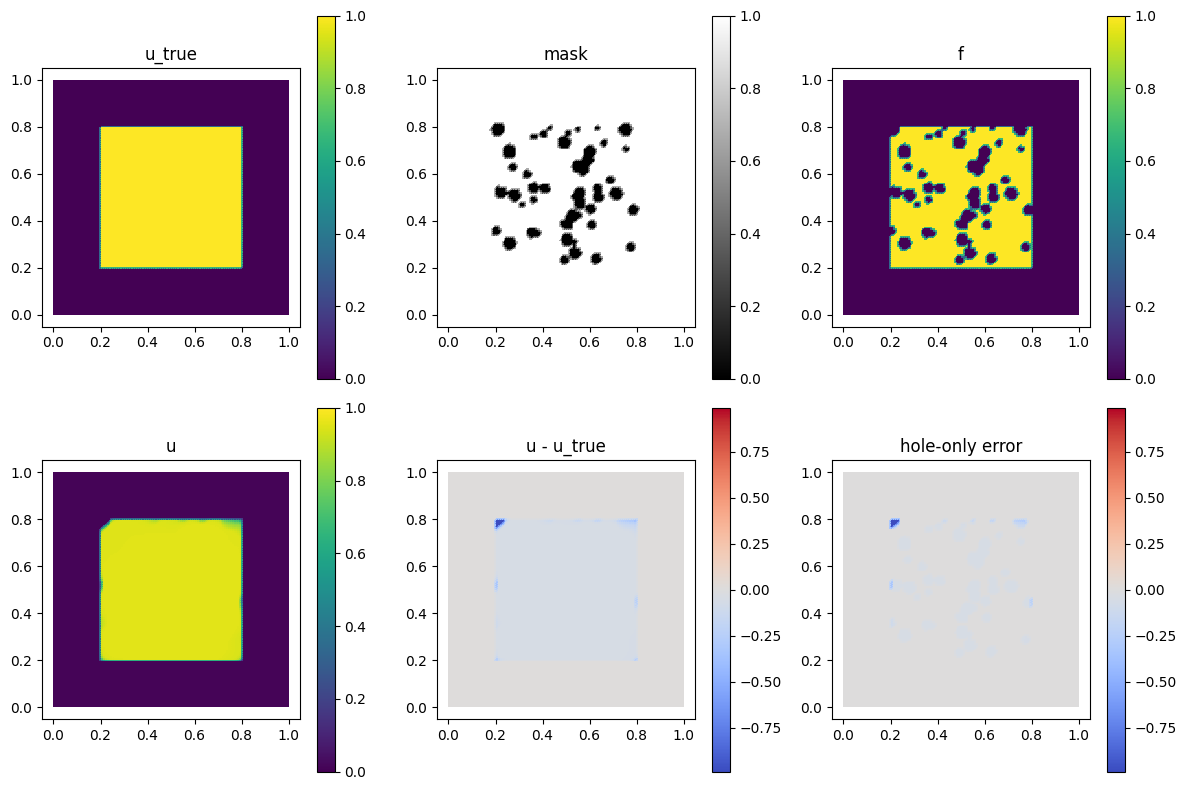

In [90]:


def plot_field(ax, data, title, fig, cmap="viridis", vmin=0.0, vmax=1.0):
    """Plot a scalar field on a triangulated mesh."""
    im = ax.tripcolor(triang, data, shading="flat", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax)


fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# $u_{true } $ground truth image
plot_field(axes[0, 0], u_true.x.array, "u_true", fig)
# m, mask with known (1) and missing (0) regions
plot_field(axes[0, 1], m.x.array, "mask", fig, cmap="gray")
# f is the damaged image
plot_field(axes[0, 2], f.x.array, "f", fig)
# u is the reconstructed image
plot_field(axes[1, 0], u.x.array, "u", fig)
# Global error
lim = np.max(np.abs(u_minus_u_true.x.array))
# $u-u_{true}$ is the global reconstruction error
plot_field(
    axes[1, 1], u_minus_u_true.x.array, "u - u_true", fig, cmap="coolwarm", vmin=-lim, vmax=lim
)
# Hole only errors
lim = np.max(np.abs(hole_error_field.x.array))
# Hole only error restricted to the missing regions
plot_field(
    axes[1, 2],
    hole_error_field.x.array,
    "hole-only error",
    fig,
    cmap="coolwarm",
    vmin=-lim,
    vmax=lim,
)
plt.tight_layout()
plt.show()


## References
```{bibliography}
   :filter: cited
   :labelprefix:
   :keyprefix: tv-
```